In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seisbench.models as sbm
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from transformers import EncodecModel
import utils as u

In [ ]:
embedded_input=False
seed=1234
u.seed_everything(seed)
print(torch.cuda.is_available())
if torch.cuda.is_available():  
    dev = "cuda" 
    map_location=None
else:  
    dev = "cpu"  
    map_location='cpu'
device = torch.device(dev)
path=os.getcwd()+'/'
path

Setting seeds
True


'c:\\Users\\Laura\\Desktop\\Laura\\Istruzione\\PhD\\Los Alamos\\Project\\Encoder\\ours\\code for users\\phase_detection/'

In [3]:
eval_df=pd.read_pickle("../reconstruction/stead_test_subset.csv")
print(eval_df.columns)
eval_df


Index(['index', 'E_channel', 'N_channel', 'Z_channel', 'back_azimuth_deg',
       'coda_end_sample', 'network_code', 'p_arrival_sample', 'p_status',
       'p_travel_sec', 'p_weight', 'receiver_code', 'receiver_elevation_m',
       'receiver_latitude', 'receiver_longitude', 'receiver_type',
       's_arrival_sample', 's_status', 's_weight', 'snr_db', 'source_depth_km',
       'source_depth_uncertainty_km', 'source_distance_deg',
       'source_distance_km', 'source_error_sec', 'source_gap_deg',
       'source_horizontal_uncertainty_km', 'source_id', 'source_latitude',
       'source_longitude', 'source_magnitude', 'source_magnitude_author',
       'source_magnitude_type', 'source_mechanism_strike_dip_rake',
       'source_origin_time', 'source_origin_uncertainty_sec', 'trace_category',
       'trace_name', 'trace_start_time', 'missing_time_from_event',
       'source_magnitude_label'],
      dtype='object')


,index,E_channel,N_channel,Z_channel,back_azimuth_deg,coda_end_sample,network_code,p_arrival_sample,p_status,p_travel_sec,...,source_magnitude_author,source_magnitude_type,source_mechanism_strike_dip_rake,source_origin_time,source_origin_uncertainty_sec,trace_category,trace_name,trace_start_time,missing_time_from_event,source_magnitude_label
0,69180,"[-0.0, -0.006526834, -0.011599667, -0.03860825...","[-0.0, -0.0016655686, 0.017617673, 0.0618087, ...","[0.0, 0.0026812945, -0.0116409315, -0.01625718...",175.0,[[2172.0]],HV,802,autopicker,1.5,...,None,ml,None,2018-07-13 13:38:47.810,None,earthquake_local,RSDD.HV_20180713133840_EV,2018-07-13 13:38:41.290,-6.52,"[0, 0, 1, 0, 0]"
1,90101,"[-200.5755, -223.68773, -254.1443, -263.09805,...","[-25.060225, -34.886604, -54.364525, -68.77422...","[255.91516, 237.93314, 178.58626, 130.66376, 1...",271.700012,[[5238.0]],CI,900,manual,14.02,...,None,mb,None,2010-04-22 14:22:02.720,0.86,earthquake_local,BAR.CI_20100422142206_EV,2010-04-22 14:22:07.740,5.02,"[0, 0, 0, 1, 0]"
2,179676,"[2.440298, -2.5949564, -4.2758465, -4.798873, ...","[24.992334, 20.990742, 13.06829, 5.9852777, 3....","[-4.3666267, -6.9156466, -11.640782, -16.57282...",313.640015,[[3603.0]],AK,900,manual,12.74,...,None,ml,None,2018-07-12 23:34:52.545,1.15,earthquake_local,CHI.AK_20180712233456_EV,2018-07-12 23:34:56.285,3.74,"[0, 0, 1, 0, 0]"
3,36809,"[-0.0, -0.037904758, -0.087882325, -0.23007753...","[0.0, 0.08645568, 0.22473973, 0.58616436, 0.79...","[0.0, 0.0076630055, 0.039201356, 0.056555204, ...",98.400002,[[3044.0]],GS,900,manual,4.19,...,None,ml,None,2015-02-28 22:03:59.860,None,earthquake_local,KAN10.GS_20150228220354_EV,2015-02-28 22:03:55.050,-4.81,"[0, 1, 0, 0, 0]"
4,53115,"[550.6599, 596.43976, 617.6446, 610.97595, 595...","[-286.6528, -257.0198, -231.17693, -221.74454,...","[1.5144447, 64.00696, 125.89976, 132.23563, 88...",21.9,[[5900.0]],AV,900,manual,20.860001,...,None,mb,None,2012-01-04 17:24:31.700,0.69,earthquake_local,RDJH.AV_20120104172442_EV,2012-01-04 17:24:43.560,11.86,"[0, 0, 0, 0, 1]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,44015,"[-0.0, 4.2638792e-05, -0.00020393876, -0.00096...","[-0.0, -0.0006057625, -0.0031870014, -0.001575...","[-0.0, -0.00068160245, -0.0040791673, -0.00390...",249.899994,[[2394.0]],PB,900,manual,8.61,...,None,md,None,2015-01-29 13:12:40.560,NaN,earthquake_local,B045.PB_20150129131239_EV,2015-01-29 13:12:40.170,-0.39,"[0, 0, 1, 0, 0]"
296,77515,"[2.633001, 1.617691, 5.6152806, 2.5140703, 1.6...","[-0.6710973, 0.36064464, -2.650949, -1.6255105...","[7.919519, 4.718674, 0.117579356, 7.6938043, 4...",324.899994,[[2762.0]],PB,1000,manual,10.49,...,None,ml,None,2013-04-05 11:51:06.270,NaN,earthquake_local,B921.PB_20130405115106_EV,2013-04-05 11:51:06.760,0.49,"[0, 0, 1, 0, 0]"
297,99309,"[-0.0, -0.017555911, -0.0479957, -0.12170298, ...","[0.0, 0.057773296, 0.15242253, 0.39579883, 0.5...","[0.0, 0.003118194, 0.0077757486, 0.014712251, ...",246.399994,[[2143.0]],AZ,900,manual,4.32,...,None,ml,None,2015-07-03 08:50:41.280,0.17,earthquake_local,LVA2.AZ_20150703085035_EV,2015-07-03 08:50:36.600,-4.68,"[0, 1, 0, 0, 0]"
298,122811,"[-811.6188, -827.6738, -821.30066, -859.14343,...","[-835.1703, -692.4747, -695.6698, -879.13654, ...","[37.678947, 20.828915, 57.19638, 140.76698, 90...",117.400002,[[3440.0]],IU,900,manual,20.059999,...,None,mb,None,2007-02-26 22:48:10.240,0.28,earthquake_local,SNZO.IU_20070226224820_EV,2007-02-26 22:48:21.300,11.06,"[0, 0, 0, 0, 1]"


In [4]:
unique_values = eval_df['p_status'].unique()
print("eval_df['p_status'] values: ",unique_values)
eval_df_manual=eval_df[eval_df['p_status']=='manual']
eval_df_automatic=eval_df[eval_df['p_status']=='automatic']
eval_df_autopicker=eval_df[eval_df['p_status']=='autopicker']
print("len(eval_df)", len(eval_df)," manual picked: ",len(eval_df_manual)," automatic picked: ",len(eval_df_automatic)," autopicked: ",len(eval_df_autopicker))#, len(eval_df_manual)+len(eval_df_automatic)+len(eval_df_autopicker))
print("We only evaluate on manually picked, for fairness:")
eval_df=eval_df[eval_df['p_status']=='manual']
eval_df=eval_df[eval_df['s_status']=='manual']
print("new len(eval_df)", len(eval_df))
print("check: ", eval_df['p_status'].unique(), eval_df['s_status'].unique())
eval_df.head()

eval_df['p_status'] values:  ['autopicker' 'manual' 'automatic']
len(eval_df) 300  manual picked:  211  automatic picked:  22  autopicked:  67
We only evaluate on manually picked, for fairness:
new len(eval_df) 192
check:  ['manual'] ['manual']


,index,E_channel,N_channel,Z_channel,back_azimuth_deg,coda_end_sample,network_code,p_arrival_sample,p_status,p_travel_sec,...,source_magnitude_author,source_magnitude_type,source_mechanism_strike_dip_rake,source_origin_time,source_origin_uncertainty_sec,trace_category,trace_name,trace_start_time,missing_time_from_event,source_magnitude_label
2,179676,"[2.440298, -2.5949564, -4.2758465, -4.798873, ...","[24.992334, 20.990742, 13.06829, 5.9852777, 3....","[-4.3666267, -6.9156466, -11.640782, -16.57282...",313.640015,[[3603.0]],AK,900,manual,12.74,...,None,ml,None,2018-07-12 23:34:52.545,1.15,earthquake_local,CHI.AK_20180712233456_EV,2018-07-12 23:34:56.285,3.74,"[0, 0, 1, 0, 0]"
3,36809,"[-0.0, -0.037904758, -0.087882325, -0.23007753...","[0.0, 0.08645568, 0.22473973, 0.58616436, 0.79...","[0.0, 0.0076630055, 0.039201356, 0.056555204, ...",98.400002,[[3044.0]],GS,900,manual,4.19,...,None,ml,None,2015-02-28 22:03:59.860,None,earthquake_local,KAN10.GS_20150228220354_EV,2015-02-28 22:03:55.050,-4.81,"[0, 1, 0, 0, 0]"
5,100637,"[0.0, 0.01767727, 0.044596184, 0.106787704, 0....","[-0.0, -0.014886639, -0.04804178, -0.1085209, ...","[0.0, 0.027316974, 0.0780459, 0.19494891, 0.25...",293.700012,[[3199.0]],TA,900,manual,14.18,...,None,ml,None,2008-02-21 17:21:29.660,0.32,earthquake_local,M11A.TA_20080221172133_EV,2008-02-21 17:21:34.840,5.18,"[0, 0, 1, 0, 0]"
6,6569,"[-82.77254, -70.03682, -51.845127, -30.951252,...","[53.33986, 49.769302, 46.075176, 43.751415, 41...","[16.893148, 11.619313, 2.901132, -6.824212, -1...",123.0,[[2925.0]],CI,1000,manual,14.74,...,CI,ml,None,2010-05-16 03:01:02.650,NaN,earthquake_local,IBP.CI_20100516030107_EV,2010-05-16 03:01:07.390,4.74,"[0, 0, 0, 1, 0]"
7,41705,"[-41.393135, -51.245693, -49.8588, -45.769077,...","[1.4143375, 11.260419, 26.100763, 37.48057, 33...","[13.367582, -4.1826334, -37.860283, -35.047497...",121.5,[[5900.0]],GS,900,manual,7.8,...,None,mb_lg,None,2015-03-16 05:48:26.840,0.76,earthquake_local,KAN13.GS_20150316054824_EV,2015-03-16 05:48:25.640,-1.20,"[0, 0, 0, 1, 0]"


In [5]:
df=eval_df[['Z_channel', 'E_channel', 'N_channel', 'p_arrival_sample', 's_arrival_sample', 'trace_name']]

In [6]:
preprocess_dataset=True #this is to make the phase arrival more randomized
df = df.dropna()
waves=np.concatenate((np.expand_dims(np.array(df["Z_channel"].tolist()),1),  np.expand_dims(np.array(df["E_channel"].tolist()),1) ,  np.expand_dims(np.array(df["N_channel"].tolist()),1)), axis=1)
labels=np.concatenate((np.expand_dims(np.array(df["p_arrival_sample"].tolist()),1),  np.expand_dims(np.array(df["s_arrival_sample"].tolist()),1)), axis=1)
trace_names_list=df["trace_name"].tolist()

if preprocess_dataset:
    waves=np.array(u.normalize_dataset(torch.tensor(waves)))
    label_width=100
    shift_range = [-2000 + label_width * 2, 1000 - label_width * 2]
    window_size = 3000  #30 seconds
    print("shift_range",shift_range)
print("waves.shape", waves.shape,"labels.shape", labels.shape)


The normalization is event-based, working on the 3 channels
shift_range [-1800, 800]
waves.shape (192, 3, 6000) labels.shape (192, 2)


In [7]:
if preprocess_dataset:
    samples = torch.zeros((len(waves), waves.shape[1], window_size))  # Adjust dimensions as needed
    itp_lists = torch.zeros((len(waves), 1))  # P-arrival time
    its_lists = torch.zeros((len(waves), 1))  # S-arrival time
    ret_shifts = torch.zeros(len(waves))  # Retain shift info
    targets = torch.zeros((len(waves), waves.shape[1], window_size))  # Assuming 3 classes for targets

    for i in range(len(waves)):
        sample=np.expand_dims(waves[i,:,:].transpose(1, 0), axis=1)
        itp_list=[[labels[i,0]]]
        its_list=[[labels[i,1]]]
        sample, itp_list, its_list, ret_shift = u.random_shift(sample, itp_list,its_list, shift_range=shift_range)
        target=u.generate_label(sample, [itp_list, its_list])
        min_start = max(0, min(int(itp_list[0][0]), int(its_list[0][0])) - window_size)
        max_start = max(0, max(int(itp_list[0][0]), int(its_list[0][0])) - window_size // 2)
        if max_start > min_start:  
            start_idx = np.random.randint(min_start, max_start + 1)
        else:
            start_idx = min_start 
        end_idx = start_idx + window_size
        if end_idx > sample.shape[0]:
            end_idx = sample.shape[0]
            start_idx = end_idx - window_size 
        select_range = [start_idx, end_idx]        
        sample, target, itp_list, its_list = u.cut_window(sample, target, itp_list, its_list, select_range)
        samples[i] = torch.tensor(sample).permute(1,2,0)
        itp_lists[i] = torch.tensor(itp_list) 
        its_lists[i] = torch.tensor(its_list)
        ret_shifts[i] = torch.tensor(ret_shift)
        targets[i] = torch.tensor(target).permute(1,2,0)

    print("samples.shape", samples.shape,"itp_lists.shape", itp_lists.shape,"its_lists.shape", its_lists.shape,"ret_shifts.shape", ret_shifts.shape,"targets.shape", targets.shape)
    waves=np.array(samples)
    labels=np.array(torch.cat((itp_lists, its_lists), dim=1))
    print("new waves.shape", waves.shape," new labels.shape", labels.shape)


samples.shape torch.Size([192, 3, 3000]) itp_lists.shape torch.Size([192, 1]) its_lists.shape torch.Size([192, 1]) ret_shifts.shape torch.Size([192]) targets.shape torch.Size([192, 3, 3000])
new waves.shape (192, 3, 3000)  new labels.shape (192, 2)


In [8]:
# shuffle:
print("Shuffle indices")
indices_sh = torch.randperm(len(waves))
print("Shuffle ae")
waves = torch.tensor(waves[indices_sh])
print("Shuffle label")
labels = torch.tensor(labels[indices_sh])
print("Shuffle trace_name")
trace_names = [trace_names_list[i] for i in indices_sh]
print("Shuffle targets")
targets = targets[indices_sh]
print(waves.shape, labels.shape, len(trace_names), targets.shape)

Shuffle indices
Shuffle ae
Shuffle label
Shuffle trace_name
Shuffle targets
torch.Size([192, 3, 3000]) torch.Size([192, 2]) 192 torch.Size([192, 3, 3000])


In [9]:
if embedded_input:
    inputte_notEmb=[]
    dset = u.WaveformDataset(waves, trace_names, labels, targets)
    d_loader=DataLoader(dset, batch_size=1, num_workers=0, shuffle=False)
    
    net_N =  EncodecModel.from_pretrained("facebook/encodec_24khz")
    net_E =  EncodecModel.from_pretrained("facebook/encodec_24khz")
    net_Z =  EncodecModel.from_pretrained("facebook/encodec_24khz")

    net_E.load_state_dict(torch.load("../models/STEAD_ch0.pth", map_location='cuda:0'))
    net_N.load_state_dict(torch.load("../models/STEAD_ch1.pth", map_location='cuda:0'))
    net_Z.load_state_dict(torch.load("../models/STEAD_ch2.pth", map_location='cuda:0'))
    
    net_N.to(device)
    net_E.to(device)
    net_Z.to(device)

    net_N.eval()
    net_E.eval()
    net_Z.eval()

    def hook(module, input, output):
        outputs["conv"] = output

    denc_X = []
    denc_names = []
    denc_labels = []    
    denc_targets = []
    # outputs = {}

    hook_handle_E = net_E.encoder.layers[15].register_forward_hook(hook)
    hook_handle_N = net_N.encoder.layers[15].register_forward_hook(hook)
    hook_handle_Z = net_Z.encoder.layers[15].register_forward_hook(hook)

    with torch.no_grad():
        print('Encoding:')
        # for idx, batch in tqdm(enumerate(d_loader), total=len(d_loader)):
        for idx, batch in enumerate(d_loader):
            E_btc = batch[0][:,2,:].unsqueeze(1).float().to(device)
            N_btc = batch[0][:,1,:].unsqueeze(1).float().to(device)
            Z_btc = batch[0][:,0,:].unsqueeze(1).float().to(device)
            inputte_notEmb.append(batch[0])
            # print("Z_btc", Z_btc.shape)
            outputs = {}
            output = net_E(E_btc)
            out_E = outputs["conv"]

            outputs = {}
            output = net_N(N_btc)
            out_N = outputs["conv"]

            outputs = {}
            output = net_Z(Z_btc)
            out_Z = outputs["conv"]
            # print("out_Z",  out_Z.shape)

            out_chs= torch.cat((out_Z, out_E,out_N), axis=1)
            # print("out_chs", out_chs.shape)

            denc_X.append(out_chs.squeeze(0))
            denc_names.append(batch[1])
            denc_labels.append(batch[2])
            denc_targets.append(batch[3])
            # print("enc_X, target,feat", len(enc_X),len(enc_target),len(enc_features))

    denc_X = torch.stack(denc_X)
    denc_names = denc_names
    denc_labels = torch.stack(denc_labels).squeeze(1)
    denc_targets = torch.stack(denc_targets).squeeze(1)

    print("denc_X",denc_X.shape, "denc_names", len(denc_names),"denc_labels",denc_labels.shape,"denc_targets",denc_targets.shape)

c:\Users\Laura\Anaconda3\envs\spectrogram_zeus\lib\site-packages\torch\nn\utils\weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


Encoding:
denc_X torch.Size([192, 384, 10]) denc_names 192 denc_labels torch.Size([192, 2]) denc_targets torch.Size([192, 3, 3000])


In [10]:
idx_dset=np.arange(len(trace_names))

train_percentage=0.8
val_percentage=0.1
test_percentage=0.1
train_len=int(len(trace_names)*train_percentage)
val_len=int(len(trace_names)*val_percentage)
test_len=int(len(trace_names)*test_percentage)
np.random.shuffle(idx_dset)
idx_dset=idx_dset.tolist()
idx_train_set=idx_dset[:train_len]
idx_val_set=idx_dset[train_len:train_len+val_len]
idx_test_set=idx_dset[train_len+val_len:]
print("len(idx_dset)", len(idx_dset),"len(idx_train_set)", len(idx_train_set),"len(idx_val_set)", len(idx_val_set),"len(idx_test_set)", len(idx_test_set))

if embedded_input:
    enc_X_tr = denc_X[idx_train_set]
    enc_names_tr = [denc_names[i] for i in idx_train_set]
    enc_labels_tr = denc_labels[idx_train_set]
    enc_targets_tr = denc_targets[idx_train_set]
    print("enc_X_tr",enc_X_tr.shape, "enc_names_tr", len(enc_names_tr),"enc_labels_tr",enc_labels_tr.shape,"enc_targets_tr",enc_targets_tr.shape)
    
    enc_X_val = denc_X[idx_val_set]
    enc_names_val = [denc_names[i] for i in idx_val_set]
    enc_labels_val = denc_labels[idx_val_set]
    enc_targets_val = denc_targets[idx_val_set]
    print("enc_X_val",enc_X_val.shape, "enc_names_val", len(enc_names_val),"enc_labels_val",enc_labels_val.shape,"enc_targets_val",enc_targets_val.shape)
    
    enc_X_test = denc_X[idx_test_set]
    enc_names_test = [denc_names[i] for i in idx_test_set]
    enc_labels_test = denc_labels[idx_test_set]
    enc_targets_test = denc_targets[idx_test_set]
    print("enc_X_test",enc_X_test.shape, "enc_names_test", len(enc_names_test),"enc_labels_test",enc_labels_test.shape,"enc_targets_test",enc_targets_test.shape)

waves_train=waves[idx_train_set]
trace_name_train = [trace_names[i] for i in idx_train_set]
labels_train=labels[idx_train_set]
targets_train=targets[idx_train_set]

waves_val=waves[idx_val_set]
trace_name_val = [trace_names[i] for i in idx_val_set]
labels_val=labels[idx_val_set]
targets_val=targets[idx_val_set]

waves_test=waves[idx_test_set]
trace_name_test = [trace_names[i] for i in idx_test_set]
labels_test=labels[idx_test_set]
targets_test=targets[idx_test_set]

if embedded_input:
    inputte_notEmb_tr = [inputte_notEmb[i] for i in idx_train_set]
    inputte_notEmb_val = [inputte_notEmb[i] for i in idx_val_set]
    inputte_notEmb_test = [inputte_notEmb[i] for i in idx_test_set]
print("Train shapes: ",waves_train.shape, len(trace_name_train), labels_train.shape, targets_train.shape )
print("Val shapes: ",waves_val.shape, len(trace_name_val), labels_val.shape, targets_val.shape )
print("Test shapes: ",waves_test.shape, len(trace_name_test), labels_test.shape, targets_test.shape )

len(idx_dset) 192 len(idx_train_set) 153 len(idx_val_set) 19 len(idx_test_set) 20
enc_X_tr torch.Size([153, 384, 10]) enc_names_tr 153 enc_labels_tr torch.Size([153, 2]) enc_targets_tr torch.Size([153, 3, 3000])
enc_X_val torch.Size([19, 384, 10]) enc_names_val 19 enc_labels_val torch.Size([19, 2]) enc_targets_val torch.Size([19, 3, 3000])
enc_X_test torch.Size([20, 384, 10]) enc_names_test 20 enc_labels_test torch.Size([20, 2]) enc_targets_test torch.Size([20, 3, 3000])
Train shapes:  torch.Size([153, 3, 3000]) 153 torch.Size([153, 2]) torch.Size([153, 3, 3000])
Val shapes:  torch.Size([19, 3, 3000]) 19 torch.Size([19, 2]) torch.Size([19, 3, 3000])
Test shapes:  torch.Size([20, 3, 3000]) 20 torch.Size([20, 2]) torch.Size([20, 3, 3000])


In [11]:
batch_size=16
if embedded_input:
    dataset_train = u.WaveformDataset(enc_X_tr,enc_names_tr,enc_labels_tr,enc_targets_tr)
    dataset_val = u.WaveformDataset(enc_X_val,enc_names_val,enc_labels_val,enc_targets_val)
    dataset_test = u.WaveformDataset(enc_X_test,enc_names_test,enc_labels_test,enc_targets_test)
else:
    dataset_train = u.WaveformDataset(waves_train, trace_name_train, labels_train,targets_train)
    dataset_val = u.WaveformDataset(waves_val, trace_name_val, labels_val,targets_val)
    dataset_test = u.WaveformDataset(waves_test, trace_name_test, labels_test,targets_test)
    

train_dl=DataLoader(dataset_train, batch_size=batch_size, num_workers=0, shuffle=True, drop_last=True)
val_dl= DataLoader(dataset_val, batch_size=batch_size, num_workers=0, shuffle=False, drop_last=True)
test_dl=DataLoader(dataset_test, batch_size=batch_size, num_workers=0, shuffle=False, drop_last=True)


In [ ]:
loss_function = nn.CrossEntropyLoss() 
softmax_eval = nn.Softmax(dim=1)

max_acc = -np.Inf
loss_history_tr = []
loss_history_val = []
loss_history_te = []  
precisionP_history_tr = []
precisionP_history_val = []
precisionP_history_te = []
recallP_history_tr = []
recallP_history_val = []
recallP_history_te = []
F1P_history_tr = []
F1P_history_val = []
F1P_history_te = []
precisionS_history_tr = []
precisionS_history_val = []
precisionS_history_te = []
recallS_history_tr = []
recallS_history_val = []
recallS_history_te = []
F1S_history_tr = []
F1S_history_val = []
F1S_history_te = []
num_epochs = 25 
learning_rate = 0.0001
init_lr = learning_rate
lr_decay = 0.99
inp_size = [enc_X_tr.shape[1] if embedded_input else waves.shape[1]][0]
out_size=target.shape[2]
print('inp_size',inp_size, 'out_size', out_size)
if embedded_input:
    model=u.PickerDecoder(num_channels=inp_size, num_classes=out_size).to(device)
else:
    # change to u.NewEncodecModel(random_model=True) to exclude the pretrained model
    model = u.NewEncodecModel().to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.001)
if embedded_input:
    best_model=type(model)(num_channels=inp_size, num_classes=out_size).to(device)
else:
    best_model=type(model)().to(device)
pytorch_total_params = sum(p.numel() for p in model.parameters())
pytorch_total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("model, pytorch_total_params: "+str(pytorch_total_params)+", pytorch_total_trainable_params: "+str(pytorch_total_trainable_params))


inp_size 384 out_size 3
model, pytorch_total_params: 355971, pytorch_total_trainable_params: 355971


In [13]:
# Load the pre-trained PhaseNet model
modelph = sbm.PhaseNet.from_pretrained("original")  # Loads the original pre-trained PhaseNet model trained on NCEDC 
modelph = modelph.to(device)


pytorch_total_params = sum(p.numel() for p in modelph.parameters())
pytorch_total_trainable_params = sum(p.numel() for p in modelph.parameters() if p.requires_grad)
print("model, pytorch_total_params: "+str(pytorch_total_params)+", pytorch_total_trainable_params: "+str(pytorch_total_trainable_params))


model, pytorch_total_params: 268443, pytorch_total_trainable_params: 268443


In [14]:
for epoch in range(num_epochs):
    model.train()
    sum_loss_tr = 0
    all_input=[]
    all_output=[]
    all_target_gaussian=[]
    all_preds=[]
    all_targets=[]
    for idx, batch in tqdm(enumerate(train_dl), total=len(train_dl)):
        optimizer.zero_grad() 
        inp = batch[0].to(device)
        trace_name_b = batch[1]
        label_b = batch[2].to(device)
        target_b = batch[3].to(device)
        if embedded_input:
            output = model(inp)
        else:
            output = model(inp)
        flat_logits = output.clone()
        flat_targets = target_b.clone()
        output=softmax_eval(output)
        all_input.append(inp.cpu().detach())
        all_output.append(output.cpu().detach())
        all_target_gaussian.append(target_b.cpu().detach())
        p_arr_pred = torch.argmax(output.cpu().detach()[:,1,:], dim=1)
        s_arr_pred = torch.argmax(output.cpu().detach()[:,2,:], dim=1)
        all_preds.append(torch.stack((p_arr_pred, s_arr_pred)))        
        p_arr_target = torch.argmax(target_b.cpu().detach()[:,1,:], dim=1)
        s_arr_target = torch.argmax(target_b.cpu().detach()[:,2,:], dim=1)
        all_targets.append(torch.stack((p_arr_target, s_arr_target)))  
        current_loss = loss_function(flat_logits, flat_targets)
        current_loss.backward()
        optimizer.step()
        sum_loss_tr += current_loss.item()
        
    all_preds=torch.stack(all_preds)
    all_targets=torch.stack(all_targets)
    all_input=torch.stack(all_input)
    all_output=torch.stack(all_output)
    all_target_gaussian=torch.stack(all_target_gaussian)
    metrics, residual, diff_p, diff_s=u.calc_performance(all_preds.permute(0, 2, 1).reshape(-1, 2), all_targets.permute(0, 2, 1).reshape(-1, 2), tol=10.0, print_metrics=False)
    curr_tr_loss = sum_loss_tr/len(train_dl)
    loss_history_tr.append(curr_tr_loss)
    precisionP_history_tr.append(metrics['P'][0])
    precisionS_history_tr.append(metrics['S'][0])
    recallP_history_tr.append(metrics['P'][1])
    recallS_history_tr.append(metrics['S'][1])
    F1P_history_tr.append(metrics['P'][2])
    F1S_history_tr.append(metrics['S'][2])
    idx_plt_l=[1, 15, -1]


    model.eval()
    with torch.no_grad():
        sum_loss_val = 0
        all_input=[]
        all_output=[]
        all_target_gaussian=[]
        all_preds=[]
        all_targets=[]
        for idx, batch in tqdm(enumerate(val_dl), total=len(val_dl)):
            inp = batch[0].to(device)
            trace_name_b = batch[1]
            label_b = batch[2].to(device)
            target_b = batch[3].to(device)
            if embedded_input:
                output = model(inp)
            else:
                output = model(inp)
            flat_logits = output.clone()
            flat_targets = target_b.clone()
            output=softmax_eval(output)
            all_input.append(inp.cpu().detach())
            all_output.append(output.cpu().detach())
            all_target_gaussian.append(target_b.cpu().detach())
            p_arr_pred = torch.argmax(output.cpu().detach()[:,1,:], dim=1)
            s_arr_pred = torch.argmax(output.cpu().detach()[:,2,:], dim=1)
            all_preds.append(torch.stack((p_arr_pred, s_arr_pred)))        
            p_arr_target = torch.argmax(target_b.cpu().detach()[:,1,:], dim=1)
            s_arr_target = torch.argmax(target_b.cpu().detach()[:,2,:], dim=1)
            all_targets.append(torch.stack((p_arr_target, s_arr_target)))             

            current_loss = loss_function(flat_logits, flat_targets)
            sum_loss_val += current_loss.item()

        all_preds=torch.stack(all_preds)
        all_targets=torch.stack(all_targets)
        all_input=torch.stack(all_input)
        all_output=torch.stack(all_output)
        all_target_gaussian=torch.stack(all_target_gaussian)
        metrics, residual, diff_p, diff_s=u.calc_performance(all_preds.permute(0, 2, 1).reshape(-1, 2), all_targets.permute(0, 2, 1).reshape(-1, 2), tol=10.0, print_metrics=False)
        curr_val_loss = sum_loss_val/len(val_dl)
        loss_history_val.append(curr_val_loss)
        precisionP_history_val.append(metrics['P'][0])
        precisionS_history_val.append(metrics['S'][0])
        recallP_history_val.append(metrics['P'][1])
        recallS_history_val.append(metrics['S'][1])
        F1P_history_val.append(metrics['P'][2])
        F1S_history_val.append(metrics['S'][2])
        sum_acc_val=metrics['P'][0]+metrics['S'][0]+metrics['P'][1]+metrics['S'][1]+metrics['P'][1]+metrics['S'][1]
        
        if sum_acc_val > max_acc:#curr_val_loss < min_loss:
            # min_loss = curr_val_loss
            max_acc = sum_acc_val
            del best_model            
            if embedded_input:
                best_model=type(model)(num_channels=inp_size, num_classes=out_size).to(device)
            else:
                best_model=type(model)().to(device)
    
            best_model.load_state_dict(model.state_dict())

            p_arr_target = torch.argmax(target_b.cpu().detach()[:,1,:], dim=1)
            s_arr_target = torch.argmax(target_b.cpu().detach()[:,2,:], dim=1)
            print("Best Epoch:", epoch+1)


    model.eval()
    with torch.no_grad():
        sum_loss_te = 0
        all_input=[]
        all_output=[]
        all_target_gaussian=[]
        all_preds=[]
        all_targets=[]
        for idx, batch in tqdm(enumerate(test_dl), total=len(test_dl)):
            inp = batch[0].to(device)
            trace_name_b = batch[1]
            label_b = batch[2].to(device)
            target_b = batch[3].to(device)
            if embedded_input:
                output = model(inp)
            else:
                output = model(inp)
            flat_logits = output.clone()
            flat_targets = target_b.clone()
            output=softmax_eval(output)
            all_input.append(inp.cpu().detach())
            all_output.append(output.cpu().detach())
            all_target_gaussian.append(target_b.cpu().detach())
            p_arr_pred = torch.argmax(output.cpu().detach()[:,1,:], dim=1)
            s_arr_pred = torch.argmax(output.cpu().detach()[:,2,:], dim=1)
            all_preds.append(torch.stack((p_arr_pred, s_arr_pred)))        
            p_arr_target = torch.argmax(target_b.cpu().detach()[:,1,:], dim=1)
            s_arr_target = torch.argmax(target_b.cpu().detach()[:,2,:], dim=1)
            all_targets.append(torch.stack((p_arr_target, s_arr_target)))             

            current_loss = loss_function(flat_logits, flat_targets)
            sum_loss_te += current_loss.item()

        all_preds=torch.stack(all_preds)
        all_targets=torch.stack(all_targets)
        all_input=torch.stack(all_input)
        all_output=torch.stack(all_output)
        all_target_gaussian=torch.stack(all_target_gaussian)
        metrics, residual, diff_p, diff_s=u.calc_performance(all_preds.permute(0, 2, 1).reshape(-1, 2), all_targets.permute(0, 2, 1).reshape(-1, 2), tol=10.0, print_metrics=False)
        curr_te_loss = sum_loss_te/len(test_dl)
        loss_history_te.append(curr_te_loss)
        precisionP_history_te.append(metrics['P'][0])
        precisionS_history_te.append(metrics['S'][0])
        recallP_history_te.append(metrics['P'][1])
        recallS_history_te.append(metrics['S'][1])
        F1P_history_te.append(metrics['P'][2])
        F1S_history_te.append(metrics['S'][2])


    print("Epoch", epoch+1, "\tTrain Loss:", curr_tr_loss, "\tVal Loss:", curr_val_loss, "\tTest Loss:", curr_te_loss)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Best Epoch: 1


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1 	Train Loss: 1.1792512072457209 	Val Loss: 1.1093331575393677 	Test Loss: 1.11005437374115


...

Epoch 24 	Train Loss: 0.30770734283659196 	Val Loss: 0.29566046595573425 	Test Loss: 0.2970578372478485


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 25 	Train Loss: 0.2951677507824368 	Val Loss: 0.2833136320114136 	Test Loss: 0.2847754955291748


  0%|          | 0/1 [00:00<?, ?it/s]

Test P: Precision=0.000, Recall=0.000, F1=0.000
Test S: Precision=0.000, Recall=0.000, F1=0.000
train idx_plt 1
train idx_plt 3
train idx_plt 6
train idx_plt 9
train idx_plt 12
train idx_plt 15
Metrics for P arrival:
MAE (s): 9.01
RMSE (s): 10.20
Metrics for S arrival:
MAE (s): 5.45
RMSE (s): 7.06
P-phase:
True=16, Positive=16, True Positive=0
Precision=0.000, Recall=0.000, F1=0.000
S-phase:
True=16, Positive=16, True Positive=0
Precision=0.000, Recall=0.000, F1=0.000


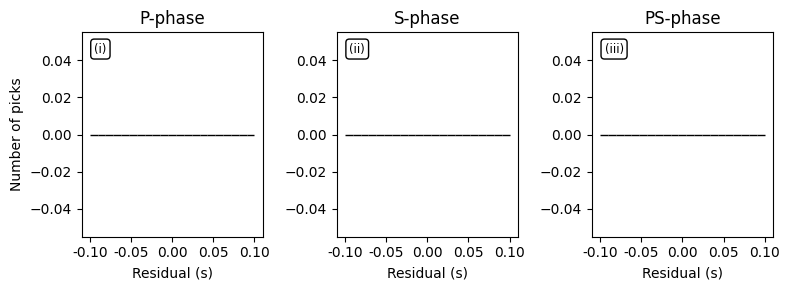

In [15]:
if embedded_input:
    best_model=type(model)(num_channels=inp_size, num_classes=out_size).to(device)
else:
    best_model=type(model)().to(device)

best_model.eval()
with torch.no_grad():#.inference_mode():#
        sum_loss_te = 0
        all_input=[]
        all_output=[]
        all_target_gaussian=[]
        all_trace_name=[]
        all_preds=[]
        all_targets=[]
        for idx, batch in tqdm(enumerate(test_dl), total=len(test_dl)):
            inp = batch[0].to(device)
            trace_name_b = batch[1]
            label_b = batch[2].to(device)
            target_b = batch[3].to(device)
            if embedded_input:
                output = best_model(inp)
            else:
                output = best_model(inp)
            flat_logits = output.clone()
            flat_targets = target_b.clone()
            output=softmax_eval(output)
            all_input.append(inp.cpu().detach())
            all_output.append(output.cpu().detach())
            all_target_gaussian.append(target_b.cpu().detach())
            all_trace_name.append(trace_name_b)
            p_arr_pred = torch.argmax(output.cpu().detach()[:,1,:], dim=1)
            s_arr_pred = torch.argmax(output.cpu().detach()[:,2,:], dim=1)
            all_preds.append(torch.stack((p_arr_pred, s_arr_pred)))        
            p_arr_target = torch.argmax(target_b.cpu().detach()[:,1,:], dim=1)
            s_arr_target = torch.argmax(target_b.cpu().detach()[:,2,:], dim=1)
            all_targets.append(torch.stack((p_arr_target, s_arr_target)))             

            current_loss = loss_function(flat_logits, flat_targets)
            sum_loss_te += current_loss.item()

        all_preds=torch.stack(all_preds)
        all_targets=torch.stack(all_targets)
        all_input=torch.stack(all_input)
        all_output=torch.stack(all_output)
        all_target_gaussian=torch.stack(all_target_gaussian)
        all_trace_name = [item for sublist in all_trace_name for item in sublist]
        metrics, residual, diff_p, diff_s=u.calc_performance(all_preds.permute(0, 2, 1).reshape(-1, 2), all_targets.permute(0, 2, 1).reshape(-1, 2), tol=10.0, print_metrics=False)
        curr_te_loss = sum_loss_te/len(test_dl)        
        
        print(f"Test P: Precision={metrics['P'][0]:.3f}, Recall={metrics['P'][1]:.3f}, F1={metrics['P'][2]:.3f}")
        print(f"Test S: Precision={metrics['S'][0]:.3f}, Recall={metrics['S'][1]:.3f}, F1={metrics['S'][2]:.3f}")
        idx_plt_l=[1, 3, 6, 9, 12, 15]
        for idx_plt in idx_plt_l:
                print("train idx_plt",idx_plt)
                if not embedded_input:
                    plt.plot(all_input[-1,idx_plt,0,:].cpu().detach().numpy())
                    plt.axvline(all_targets[-1,0,idx_plt], color="r", label="real p")
                    plt.axvline(all_targets[-1,1,idx_plt], color="g", label="real s")

                    plt.axvline(all_preds[-1,0,idx_plt], color="magenta", label="pred p")
                    plt.axvline(all_preds[-1,1,idx_plt], color="cyan", label="pred s")
                    plt.title("input")
                    plt.legend()
                    plt.show()

all_preds.reshape(-1,2).shape
print("Metrics for P arrival:")
print(f"MAE (s): {mean_absolute_error(all_targets[:,0,:].flatten(), all_preds[:,0,:].flatten())*0.01:.2f}")
print(f"RMSE (s): {np.sqrt(mean_squared_error(all_targets[:,0,:].flatten(), all_preds[:,0,:].flatten()))*0.01:.2f}")
print("Metrics for S arrival:")
print(f"MAE (s): {mean_absolute_error(all_targets[:,1,:].flatten(), all_preds[:,1,:].flatten())*0.01:.2f}")
print(f"RMSE (s): {np.sqrt(mean_squared_error(all_targets[:,1,:].flatten(), all_preds[:,1,:].flatten()))*0.01:.2f}")

metrics, residual, diff_p, diff_s=u.calc_performance(all_preds.reshape(-1,2), all_targets.reshape(-1,2), tol=10.0)
u.plot_residual(diff_p, diff_s, residual, tol=10.0)